# 03 · Optimisation and training: three classifiers aimed at ≥ 0.89

**Target:** Accuracy, Sensitivity, Specificity, Precision and F1 ≥ 0.89 on Train and Test (one-vs-rest, support-weighted).

| Step | What changes | Why |
|---|---|---|
| 1 | 5-D latent basis C, I, L, M, N (notebook 02) | complete, non-redundant description of the informative block |
| 2 | class-conditional Gaussian mixture, 2 full-covariance components per genre | each genre is about two elongated Gaussian clusters |
| 3 | semi-supervised EM with the 400 shows of unknown genre (feature values only) | sharper cluster shapes from 67% more shows |
| 4 | XGBoost and RBF-SVM trained on the mixture's clipped log-posteriors | discriminative boundary on top of the cluster geometry |
| 5 | RandomizedSearchCV (5-fold), score = **worst of the 5 weighted metrics**, gap guard ≤ 0.05 | the search lifts the metric furthest from target |

Classifiers kept: **SSGMM** (semi-supervised Gaussian mixture), **XGBoost** (mixture posteriors + inputs) and **SVM-RBF** (mixture posteriors). A deep MLP on the same features was also optimised and is reported as a screened model (it ranked fourth). Blank inputs are marginalised by the mixture instead of imputed. `evaluation_*.joblib` = fit on 480 shows; `production_*.joblib` = refit on all 600.

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/tv-genre-classification


In [2]:
# Rebuild the cleaned data if it is missing (fresh clone)
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()
# Train once if the saved models are missing (about 2 minutes)
if not all(cfg.model_file(m, "production").exists() for m in cfg.MODEL_NAMES):
    from src.features import build_features as bf
    from src.models import train_model as tm
    bf.run(); tm.run(); plt.close("all")
elif not cfg.SELECTED_FEATURES_FILE.exists():
    from src.features import build_features as bf
    bf.run(); plt.close("all")
from src.models import train_model as tm
from src.utils import load_json

In [3]:
for name, space in tm.SPACES.items():
    print(name)
    for k, v in space.items():
        d = getattr(v, "dist", None)
        print(f"   {k:22s}", d.name if d else v, getattr(v, "args", ""))

SSGMM
   clf__n_components      [1, 2, 3] 
   clf__reg_covar         loguniform (1e-05, 0.01)
   clf__prior_power       uniform (0.25, 0.75)
   clf__use_unlabelled    [True, False] 
XGBoost
   gmm__n_components      [2, 3] 
   gmm__clip              [5.0, 10.0, 20.0] 
   gmm__components        [True, False] 
   clf__n_estimators      randint (100, 500)
   clf__max_depth         randint (1, 5)
   clf__learning_rate     loguniform (0.01, 0.2)
   clf__subsample         uniform (0.6, 0.4)
   clf__colsample_bytree  uniform (0.5, 0.5)
   clf__min_child_weight  randint (1, 15)
   clf__gamma             uniform (0, 3)
   clf__reg_lambda        loguniform (0.01, 20)
   clf__reg_alpha         loguniform (0.001, 5)
SVM-RBF
   gmm__n_components      [2, 3] 
   gmm__clip              [3.0, 5.0, 10.0] 
   gmm__components        [True, False] 
   clf__C                 loguniform (0.1, 30.0)
   clf__gamma             loguniform (0.003, 1)
   clf__class_weight      [None, 'balanced'] 
DeepMLP
   gmm__

## Train or load
Set `RETRAIN = True` to retrain (about 3 minutes).

In [4]:
RETRAIN = False
if RETRAIN:
    tm.run(); plt.close("all")
meta = load_json(cfg.MODEL_METADATA_FILE)
pd.DataFrame({m: {k: v for k, v in d.items() if k in ("deployed", "cv_score_min_weighted", "cv_score_sd", "cv_train_score",
                                                       "gap_guard_met", "train_seconds")}
              for m, d in meta["models"].items()}).T

,deployed,cv_score_min_weighted,cv_score_sd,cv_train_score,gap_guard_met,train_seconds
SSGMM,True,0.904126,0.031536,0.913405,True,19.4
XGBoost,True,0.904255,0.029027,0.925983,True,43.3
SVM-RBF,True,0.899359,0.036912,0.913818,True,33.1
DeepMLP,False,0.896057,0.038119,0.916801,True,35.3


In [5]:
for m, d in meta["models"].items():
    print(m, {k: (round(v, 4) if isinstance(v, float) else v) for k, v in d["best_params"].items()})

SSGMM {'clf__n_components': 2, 'clf__prior_power': 0.3233, 'clf__reg_covar': 0.0011, 'clf__use_unlabelled': True}
XGBoost {'clf__colsample_bytree': 0.7744, 'clf__gamma': 2.0757, 'clf__learning_rate': 0.0705, 'clf__max_depth': 1, 'clf__min_child_weight': 4, 'clf__n_estimators': 260, 'clf__reg_alpha': 0.0012, 'clf__reg_lambda': 0.4269, 'clf__subsample': 0.6715, 'gmm__clip': 20.0, 'gmm__components': True, 'gmm__n_components': 2}
SVM-RBF {'clf__C': 0.8468, 'clf__class_weight': None, 'clf__gamma': 0.0087, 'gmm__clip': 3.0, 'gmm__components': True, 'gmm__n_components': 2, 'clf__probability': True}
DeepMLP {'clf__batch_size': 64, 'clf__class_weight': None, 'clf__dropout': 0.2474, 'clf__lr': 0.0009, 'clf__n_layers': 1, 'clf__weight_decay': 0.0, 'clf__width': 128, 'gmm__clip': 5.0}


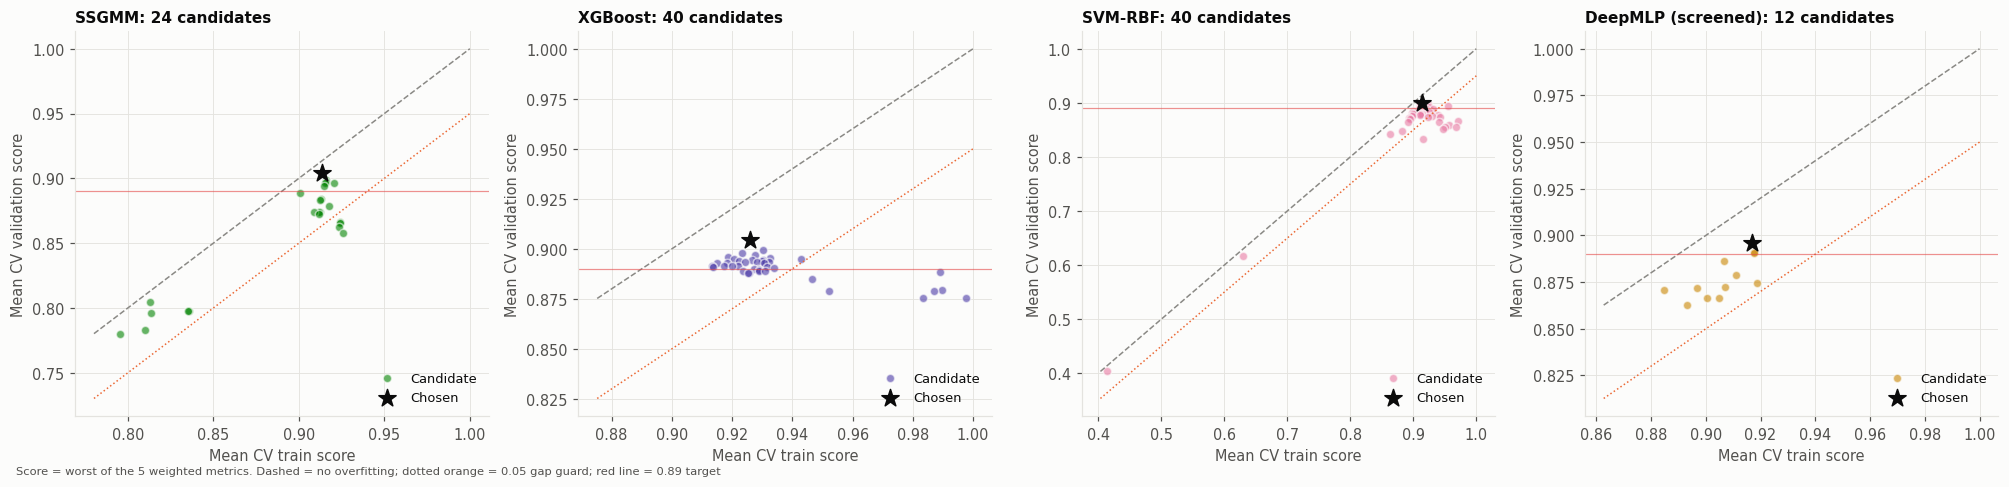

In [6]:
search = {n: pd.read_csv(cfg.TABLES_DIR / f"search_{n.lower().replace('-', '_')}.csv")
          for n in cfg.MODEL_NAMES + cfg.SCREENED_MODELS}
tm.plot_search(search);

## Optimisation steps
Repeated 5×2 CV on the training split; each step is cumulative.

,step,score,sd,accuracy,features
0,0 always Comedy,0.3752,0.0051,0.6125,"C,I,L,M,N"
1,"1 previous release: RBF-SVM, 7 features",0.7839,0.0434,0.7938,"A,C,G,J,L,M,N"
2,"2 same SVM, 5-D latent basis",0.7888,0.0446,0.7948,"C,I,L,M,N"
3,"3 Gaussian mixture, 2 per genre",0.8852,0.0298,0.8948,"C,I,L,M,N"
4,4 + 400 unlabelled shows (semi-supervised),0.8970,0.0213,0.9083,"C,I,L,M,N"
5,5 tuned SSGMM,0.9041,0.0315,NaN,"C,I,L,M,N"
6,5 tuned XGBoost,0.9043,0.0290,NaN,"C,I,L,M,N"
7,5 tuned SVM-RBF,0.8994,0.0369,NaN,"C,I,L,M,N"
8,5 tuned DeepMLP,0.8961,0.0381,NaN,"C,I,L,M,N"


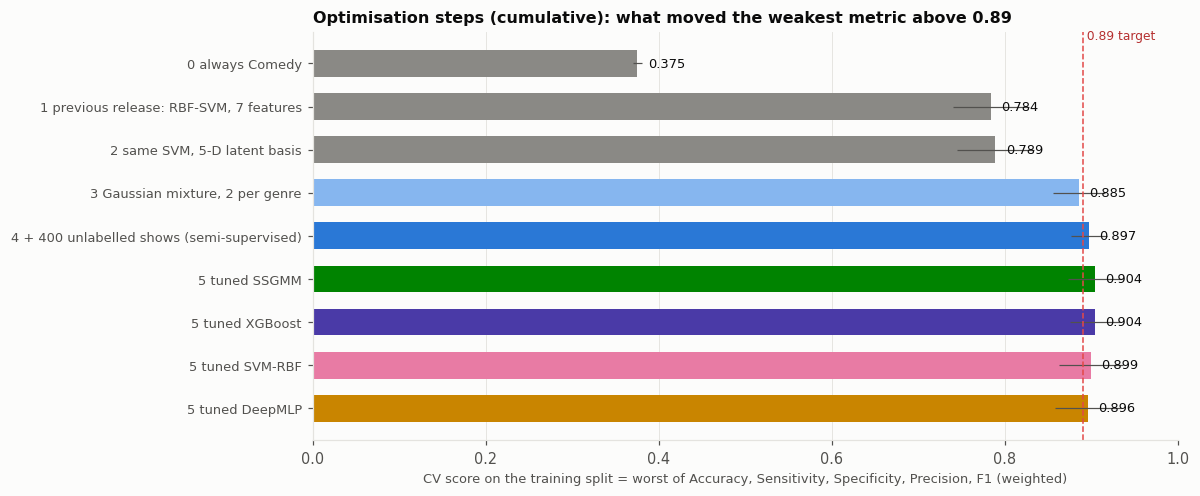

In [7]:
lad = pd.read_csv(cfg.TABLES_DIR / "optimisation_steps.csv")
tm.plot_ladder(lad)
lad.round(4)

**Reading the ladder.** The previous release (RBF-SVM on 7 features) reached a weakest-metric score of about 0.78. Moving the same SVM to the latent basis changes little; the jump comes from modelling the cluster shape (Gaussian mixture, about +0.10), then from the 400 unlabelled shows (about +0.01), then tuning. All three deployed models clear 0.89 in CV on the training split, each with a train-validation gap well under 0.05.